In [1]:
import matplotlib.pyplot as plt
from deepface import DeepFace
from tqdm.auto import tqdm
import glob
import ast
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
from api_utils import Utils

# Dataset

In [2]:
import os
import requests
import zipfile
import io

data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)
zip_path = os.path.join(data_dir, "family_photos.zip")
extract_dir = os.path.join(data_dir, "family_photos")

url = "https://www.dropbox.com/scl/fi/yg0f2ynbzzd2q4nsweti5/family_photos.zip?rlkey=00oeuiii3jgapz2b1bfj0vzys&dl=1"

if not os.path.exists(extract_dir):
    print("Downloading dataset...")
    response = requests.get(url)
    response.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(response.content)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    
    print(f"Done! Dataset is available at '{extract_dir}'")
else:
    print(f"Dataset already exists at '{extract_dir}', skipping download.")

Dataset already exists at './data\family_photos', skipping download.


In [3]:
def show_imgs(file_paths):
    n = len(file_paths)
    plt.figure(figsize=(4*n, 4))  # width scales with number of images
    
    for i, file_path in enumerate(file_paths):
        full_path = os.path.join(extract_dir, file_path)
        img = plt.imread(full_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis('off')

        title = os.path.basename(os.path.dirname(file_path))
        plt.title(title.capitalize())

    plt.tight_layout()
    plt.show()

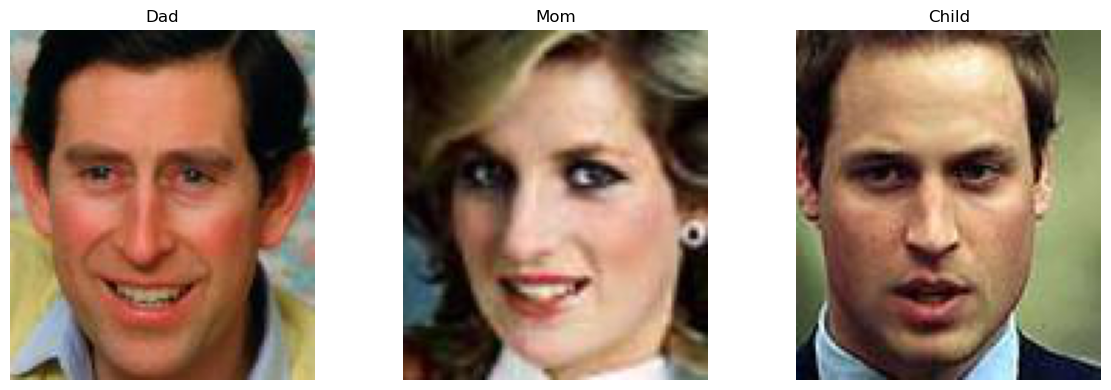

In [4]:
images = [
    'family/dad/P06260_face5.jpg',
    'family/mom/P04407_face2.jpg',
    'family/child/P04414_face1.jpg'
]

show_imgs(images)

# Embeddings

In [5]:
def generate_face_embeddings(vector_file, image_dir, model_name='Facenet'):
    # Delete if exists
    try:
        os.remove(vector_file)
    except FileNotFoundError:
        pass

    # Write 
    with open(vector_file, 'w') as f:
        persons = [p for p in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, p))]
        
        for person in persons:
            person_dir = os.path.join(image_dir, person)
            image_files = glob.glob(os.path.join(person_dir, '*'))

            for file in tqdm(image_files, desc=f"Processing {person}"):
                try:
                    vector = DeepFace.represent(img_path=file, model_name=model_name, enforce_detection=True)[0]['embedding']
                    f.write(f"{person}:{os.path.basename(file)}:{vector}\n")
                except Exception as e:
                    print(f"Error in {file}: {e}")

            print(f"Done processing {person}!")

        print('---')
        print('Done all!')

In [6]:
VECTOR_FILE = './data/face_embeddings.vec'
IMAGE_DIR = './data/family_photos/family'
generate_face_embeddings(vector_file=VECTOR_FILE, image_dir=IMAGE_DIR)

Processing child:   0%|          | 0/93 [00:00<?, ?it/s]

Error in ./data/family_photos/family\child\P06313_face2.jpg: Face could not be detected in ./data/family_photos/family\child\P06313_face2.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\child\P06324_face0.jpg: Face could not be detected in ./data/family_photos/family\child\P06324_face0.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\child\P06333_face1.jpg: Face could not be detected in ./data/family_photos/family\child\P06333_face1.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\child\P11923_face2.jpg: Face could not be detected in ./data/family_photos/family\child\P11923_face2.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photo

Processing dad:   0%|          | 0/70 [00:00<?, ?it/s]

Error in ./data/family_photos/family\dad\P06262_face1.jpg: Face could not be detected in ./data/family_photos/family\dad\P06262_face1.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\dad\P06263_face2.jpg: Face could not be detected in ./data/family_photos/family\dad\P06263_face2.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\dad\P06285_face0.jpg: Face could not be detected in ./data/family_photos/family\dad\P06285_face0.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\dad\P06304_face0.jpg: Face could not be detected in ./data/family_photos/family\dad\P06304_face0.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\dad\P06

Processing mom:   0%|          | 0/78 [00:00<?, ?it/s]

Error in ./data/family_photos/family\mom\P04409_face2.jpg: Face could not be detected in ./data/family_photos/family\mom\P04409_face2.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\mom\P06284_face3.jpg: Face could not be detected in ./data/family_photos/family\mom\P06284_face3.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\mom\P06294_face1.jpg: Face could not be detected in ./data/family_photos/family\mom\P06294_face1.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\mom\P06295_face1.jpg: Face could not be detected in ./data/family_photos/family\mom\P06295_face1.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.
Error in ./data/family_photos/family\mom\P06

# t-SNE for Visualiztion

In [7]:
def plot_tsne(perplexity=50, learning_rate=200, vector_file=VECTOR_FILE):
    pca = PCA(n_components=32)
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=learning_rate, n_iter=1000, random_state=42)
    
    vectors = []
    labels = []
    
    with open(vector_file, 'r') as f:
        for line in tqdm(f, desc="Loading embeddings"):
            p, image_file, vector = line.strip().split(':')
            vectors.append(ast.literal_eval(vector))
            labels.append(p)
    
    vectors = np.array(vectors)
    
    # PCA reduces embedding size from 128 to 32
    vectors_after_pca = pca.fit_transform(vectors)
    variance_retained = np.sum(pca.explained_variance_ratio_)
    print(f'PCA retains {variance_retained:.02f} variance overall')
    
    # t-SNE reduces again from 32 to 2
    vectors_after_tsne = tsne.fit_transform(vectors_after_pca)
    
    # Plot
    plt.figure(figsize=(8,5))
    person2color = {'dad':'#ee8933', 'child':'#4fad5b', 'mom':'#4c93db'}
    for person in person2color:
        indices = [idx for idx, label in enumerate(labels) if label == person]
        plt.scatter(
            vectors_after_tsne[indices, 0],
            vectors_after_tsne[indices, 1],
            alpha=0.5,
            label=person,
            color=person2color[person]
        )
        
    plt.title(f't-SNE scatter plot [perplexity={perplexity}, lr={learning_rate}]')
    plt.legend(loc='best', frameon=True)
    plt.show()

Loading embeddings: 0it [00:00, ?it/s]

PCA retains 0.92 variance overall


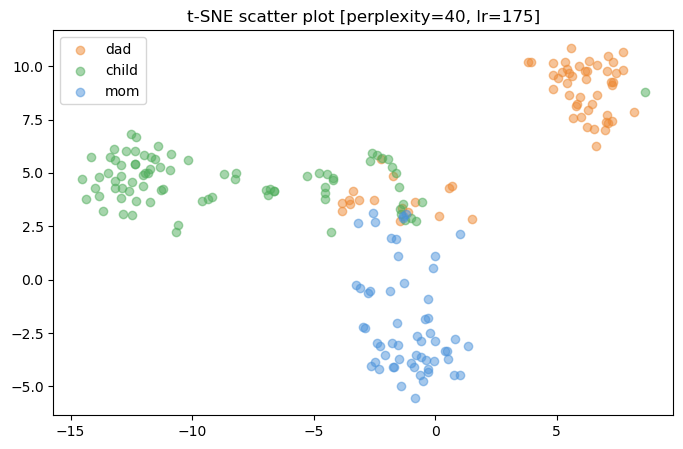

In [8]:
plot_tsne(perplexity=40, learning_rate=175)

# Upsert to Vector DB

In [9]:
face_index = Utils.create_index('face-index', dimension=128)

Index 'face-index' already exists → deleting ...
Deleted 'face-index' successfully!
Creating index 'face-index' ...
Index 'face-index' created successfully!


In [10]:
def upsert_embeddings(vector_file=VECTOR_FILE, index=face_index):
    vectors = []
    persons = []
    img_files = []
    
    with open(vector_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            p, file, vector = line.split(':')
            vectors.append(ast.literal_eval(vector))
            persons.append(p)
            img_files.append(file)

    all_zip = zip(persons, vectors, img_files)
    records = list(
        map(lambda r: {
            'id': f'{r[0]}-{r[2]}',
            'values': r[1],
            'metadata': {
                'person': r[0],
                'img_file': r[2]
            }
        }, all_zip)
    )

    index.upsert(records)

In [11]:
upsert_embeddings()

In [12]:
face_index.describe_index_stats()

{'dimension': 128,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 203}},
 'total_vector_count': 203,
 'vector_type': 'dense'}

# Find Similar Images

In [13]:
def show_image(img_file):
    img = plt.imread(img_file)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

In [14]:
def find_most_similar(img_file, person_to_find, index=face_index, embedding_model='Facenet', top_k=1):
    full_path = os.path.join(extract_dir, img_file)
    
    embedding = DeepFace.represent(img_path=full_path, model_name=embedding_model, enforce_detection=True)[0]['embedding']
    
    results = index.query(
        vector=embedding,
        filter={"person": {"$eq": person_to_find}},
        top_k=top_k,
        include_metadata=True
    )
    
    if results['matches']:
        best_match = results['matches'][0]
        best_score = best_match['score']
        match_file = best_match['metadata']['img_file']
        match_path = os.path.join(extract_dir, f'family/{person_to_find}', match_file)

        fig, axes = plt.subplots(1,2, figsize=(2*6,4))

        axes[0].imshow(plt.imread(full_path))
        axes[0].set_title("Query")
        axes[0].axis('off')

        axes[1].imshow(plt.imread(match_path))
        axes[1].set_title(f"Most similar {person_to_find} image ({best_score:.04f}): {match_file}")
        axes[1].axis('off')

        plt.show()
        
    else:
        print(f"No match found for person = {person_to_find}")

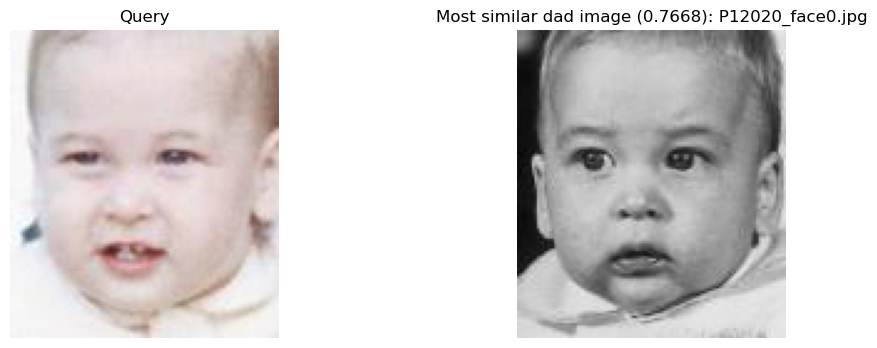

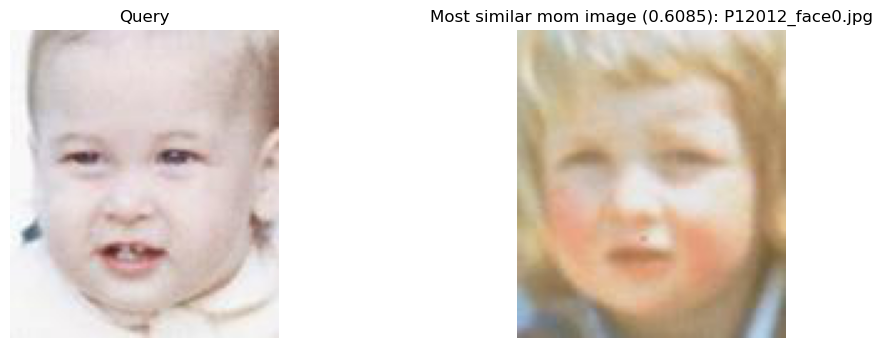

In [15]:
child_img = 'family/child/P11983_face0.jpg'
find_most_similar(child_img, person_to_find='dad')
find_most_similar(child_img, person_to_find='mom')

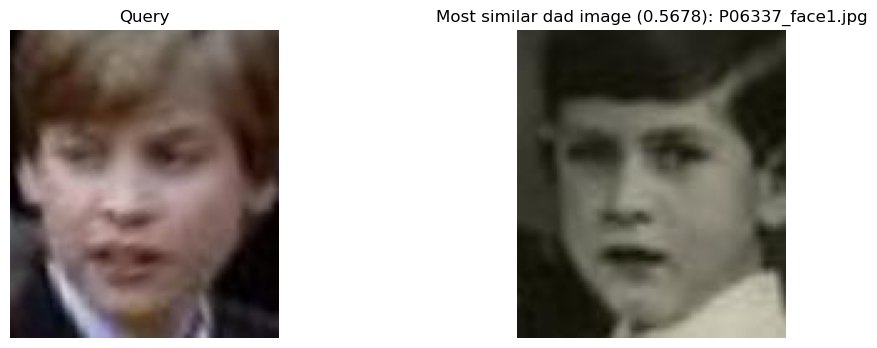

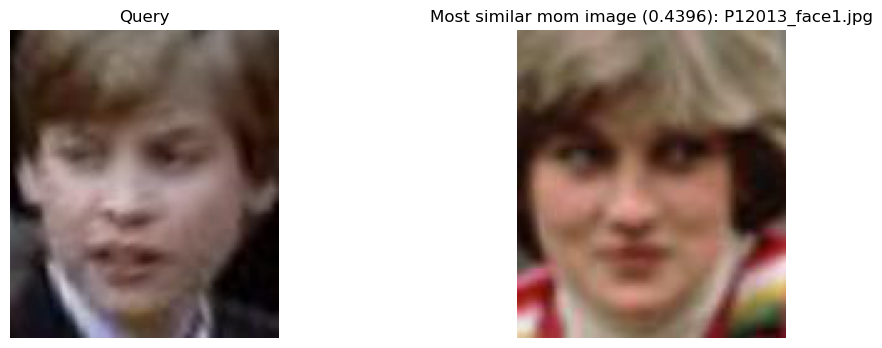

In [16]:
child_img = 'family/child/P11974_face5.jpg'
find_most_similar(child_img, person_to_find='dad')
find_most_similar(child_img, person_to_find='mom')

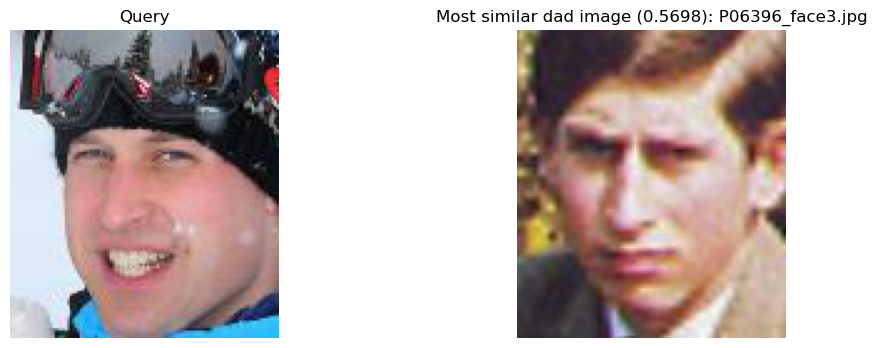

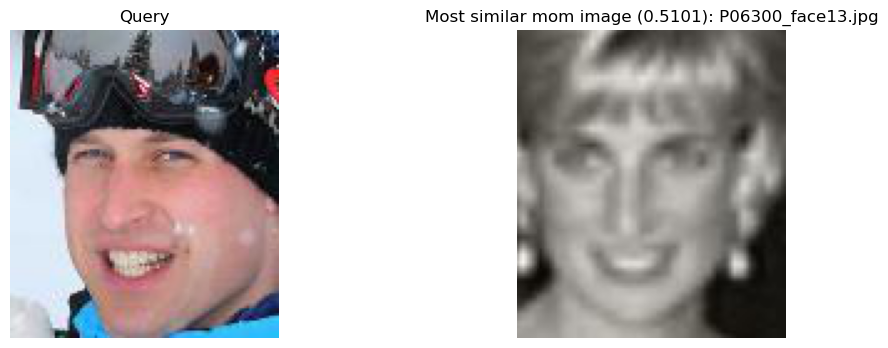

In [17]:
child_img = 'family/child/P11949_face0.jpg'
find_most_similar(child_img, person_to_find='dad')
find_most_similar(child_img, person_to_find='mom')

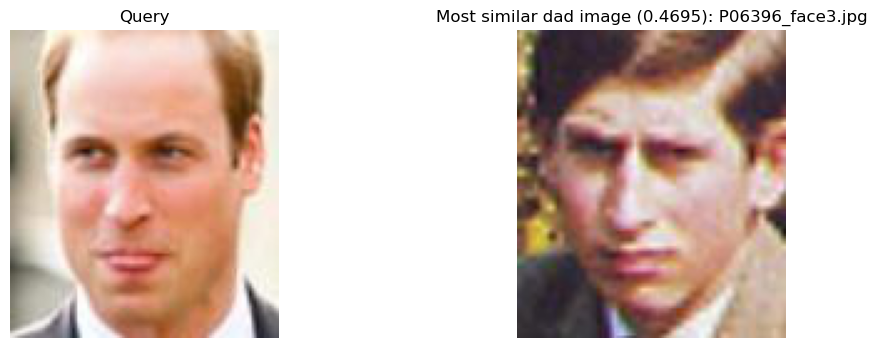

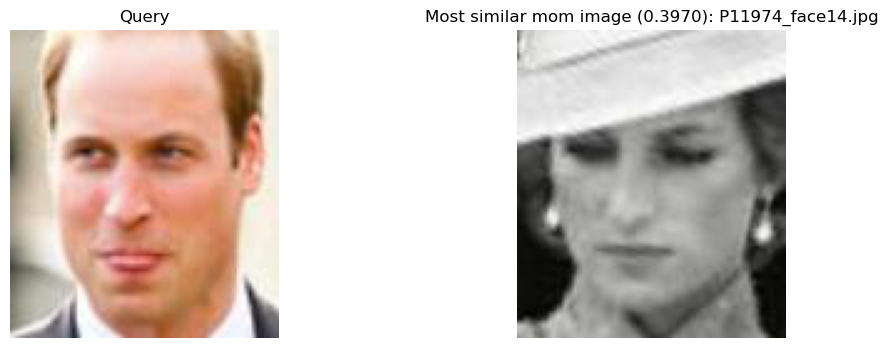

In [18]:
child_img = 'family/child/P11907_face1.jpg'
find_most_similar(child_img, person_to_find='dad')
find_most_similar(child_img, person_to_find='mom')